In [ ]:
from nrem_sc.constants import PROCESSED_DATA_PATH
from pathlib import Path

import re
import numpy as np
import pynapple as nap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "font.size":         26,
    "axes.titlesize":    26,
    "axes.labelsize":    26,
    "xtick.labelsize":   22,
    "ytick.labelsize":   22,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    "legend.frameon":    False,
    "figure.constrained_layout.use": True,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

DECODED_DATA_PATH = Path("D:\\common_datasets\\nrem_sc")
UNITS = ['83b', '85b', '116b']
UNIT = UNITS[2]

sleep_states = nap.load_file(PROCESSED_DATA_PATH / UNIT / "sleep.npz")
session = nap.load_file(PROCESSED_DATA_PATH / UNIT / "sessions_labeled.npz")

### Detect sweeps

In [2]:
def extract_sweeps(tdf, label='continuous', min_gap_ms=50):
    epochs = tdf[tdf['state'] == label].find_support(min_gap=min_gap_ms, time_units='ms')
    
    if len(epochs) == 0:
        return pd.DataFrame()

    # Single restrict call for ALL epochs
    all_data = tdf.restrict(epochs)
    pos = all_data['position'].values
    times = all_data.times('s')

    # Assign each sample to its epoch via searchsorted
    starts = epochs['start']
    epoch_idx = np.searchsorted(starts, times, side='right') - 1

    # Split arrays at epoch boundaries
    split_at = np.flatnonzero(np.diff(epoch_idx)) + 1
    pos_chunks = np.split(pos, split_at)
    time_chunks = np.split(times, split_at)

    durations = np.empty(len(pos_chunks))
    net_disp  = np.empty(len(pos_chunks))
    path_len  = np.empty(len(pos_chunks))
    integral  = np.empty(len(pos_chunks))
    n_samples = np.empty(len(pos_chunks), dtype=int)

    for i, (p, t) in enumerate(zip(pos_chunks, time_chunks)):
        uw = np.unwrap(p, period=360)
        durations[i] = t[-1] - t[0]
        net_disp[i]  = np.diff(uw).sum()
        path_len[i]  = np.abs(np.diff(uw)).sum()
        integral[i]  = np.sum(p-p[0])
        n_samples[i] = len(p)

    mask = n_samples >= 2
    return pd.DataFrame({
        'duration': durations[mask],
        'net_displacement': net_disp[mask],
        'path_length': path_len[mask],
        'integral': integral[mask],
        'n_samples': n_samples[mask],
    })

In [4]:
tdf = nap.load_file(DECODED_DATA_PATH / UNIT / "states_combined.npz").as_dataframe()
tdf['position'] = nap.load_file(DECODED_DATA_PATH / UNIT / "position_combined.npz").as_series()
tdf['condition'] = 'pre_ttx'
post_idx = tdf.index > session[session['label'] == 'ttx']['start'].item()
tdf.loc[post_idx, 'condition'] = 'post_ttx'
tdf

,continuous,fragmented,stationary,position,condition
1551.34775,0.316732,0.076878,0.606390,4.499943,pre_ttx
1551.34875,0.316456,0.073042,0.610503,4.499943,pre_ttx
1551.34975,0.316150,0.069215,0.614635,4.499943,pre_ttx
1551.35075,0.315815,0.065398,0.618787,4.499943,pre_ttx
1551.35175,0.315450,0.061589,0.622961,4.499943,pre_ttx
...,...,...,...,...,...
62109.34595,0.155073,0.681594,0.163333,71.499092,post_ttx
62109.34695,0.157669,0.676541,0.165789,71.499092,post_ttx
62109.34795,0.160240,0.671532,0.168227,71.499092,post_ttx
62109.34895,0.162790,0.666560,0.170650,71.499092,post_ttx


In [5]:
threshold = 0.5
dfs = []
for condition in ['pre_ttx', 'post_ttx']:
    data = tdf[tdf['condition'] == condition].copy(deep=True)

    # Determine the state if p>threshold, otherwise 'mixture'
    labels = data[['continuous', 'fragmented', 'stationary']]
    data['state'] = np.where(labels.max(axis=1) > threshold, labels.idxmax(axis=1), 'mixture')

    # Assign sleep state
    data['sleep_state'] = 'unknown'   
    for ep in sleep_states:
        start, end = ep['start'].item(), ep['end'].item()
        if start > data.index[-1]:
            break
        valid = (data.index > start) & (data.index < end)
        data.loc[valid, 'sleep_state'] = ep['state'].item()
    
    # Extract sweeps
    data = nap.TsdFrame(data)
    sweeps = extract_sweeps(data[data['sleep_state'] == 'nrem'], label='continuous', min_gap_ms=50)
    sweeps['condition'] = condition
    sweeps['sleep_state'] = 'nrem'
    dfs.append(sweeps)

sweeps = pd.concat(dfs)

# Partition sweeps into quartiles based on duration
sweeps['quartile'] = pd.qcut(sweeps['duration'], 4, labels=False)
# Compute velocity
sweeps['velocity'] = sweeps['net_displacement']/sweeps['duration']

# Stats
stats = sweeps[sweeps['sleep_state'] == 'nrem']['duration'].describe()
stats

count    37338.000000
mean         0.164201
std          0.139465
min          0.001000
25%          0.062000
50%          0.130000
75%          0.228000
max          1.780000
Name: duration, dtype: float64

### Visualize

In [54]:
stats

count    37338.000000
mean         0.164201
std          0.139465
min          0.001000
25%          0.062000
50%          0.130000
75%          0.228000
max          1.780000
Name: duration, dtype: float64

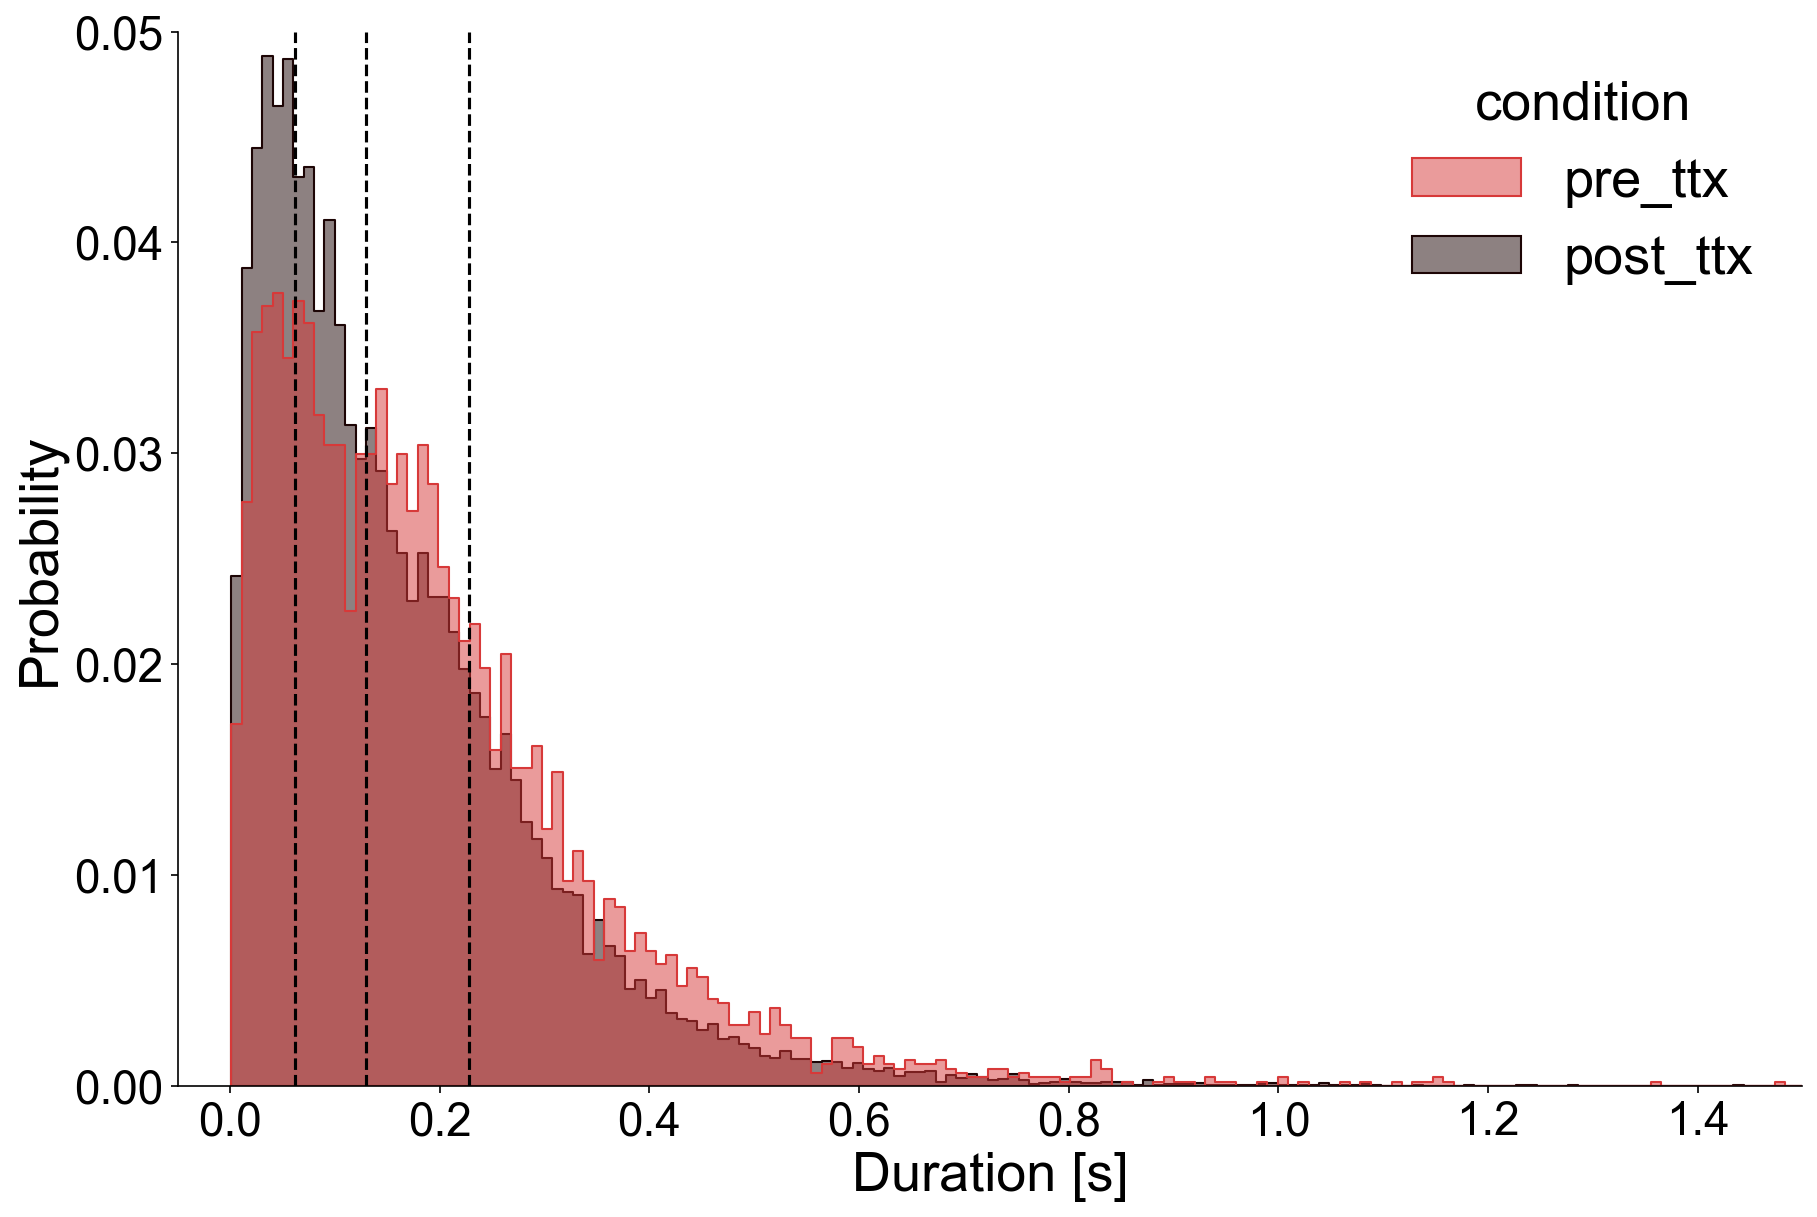

In [ ]:
from nrem_sc.constants import INTERIM_DATA_PATH

fig, ax = plt.subplots(figsize=(12, 8))

palette = ["#d73939", "#1d0505ff"]
hist_kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette)
# fig.suptitle(f'Continuous Sweep Durations in NREM (Threshold: {threshold*100:.0f}%)(Mouse {UNIT})', fontsize=18)

# fig.suptitle(f'Sweep Durations in NREM')

ax = sns.histplot(data=sweeps[sweeps['sleep_state'] == 'nrem'], x='duration', hue='condition', **hist_kwargs, ax=ax)
ax.set_xlim(-.05, 1.5)
ax.set_ylim(0, 0.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('Duration [s]')

for x in [stats['25%'], stats['50%'], stats['75%']]:
    ax.axvline(x=x, linewidth=1.5, linestyle='--', color='black')

# fig.tight_layout()
fig.savefig(INTERIM_DATA_PATH / UNIT / 'nrem_sweep_durations_partitioned.pdf', format='pdf', dpi=1200)

(-500.0, 500.0)

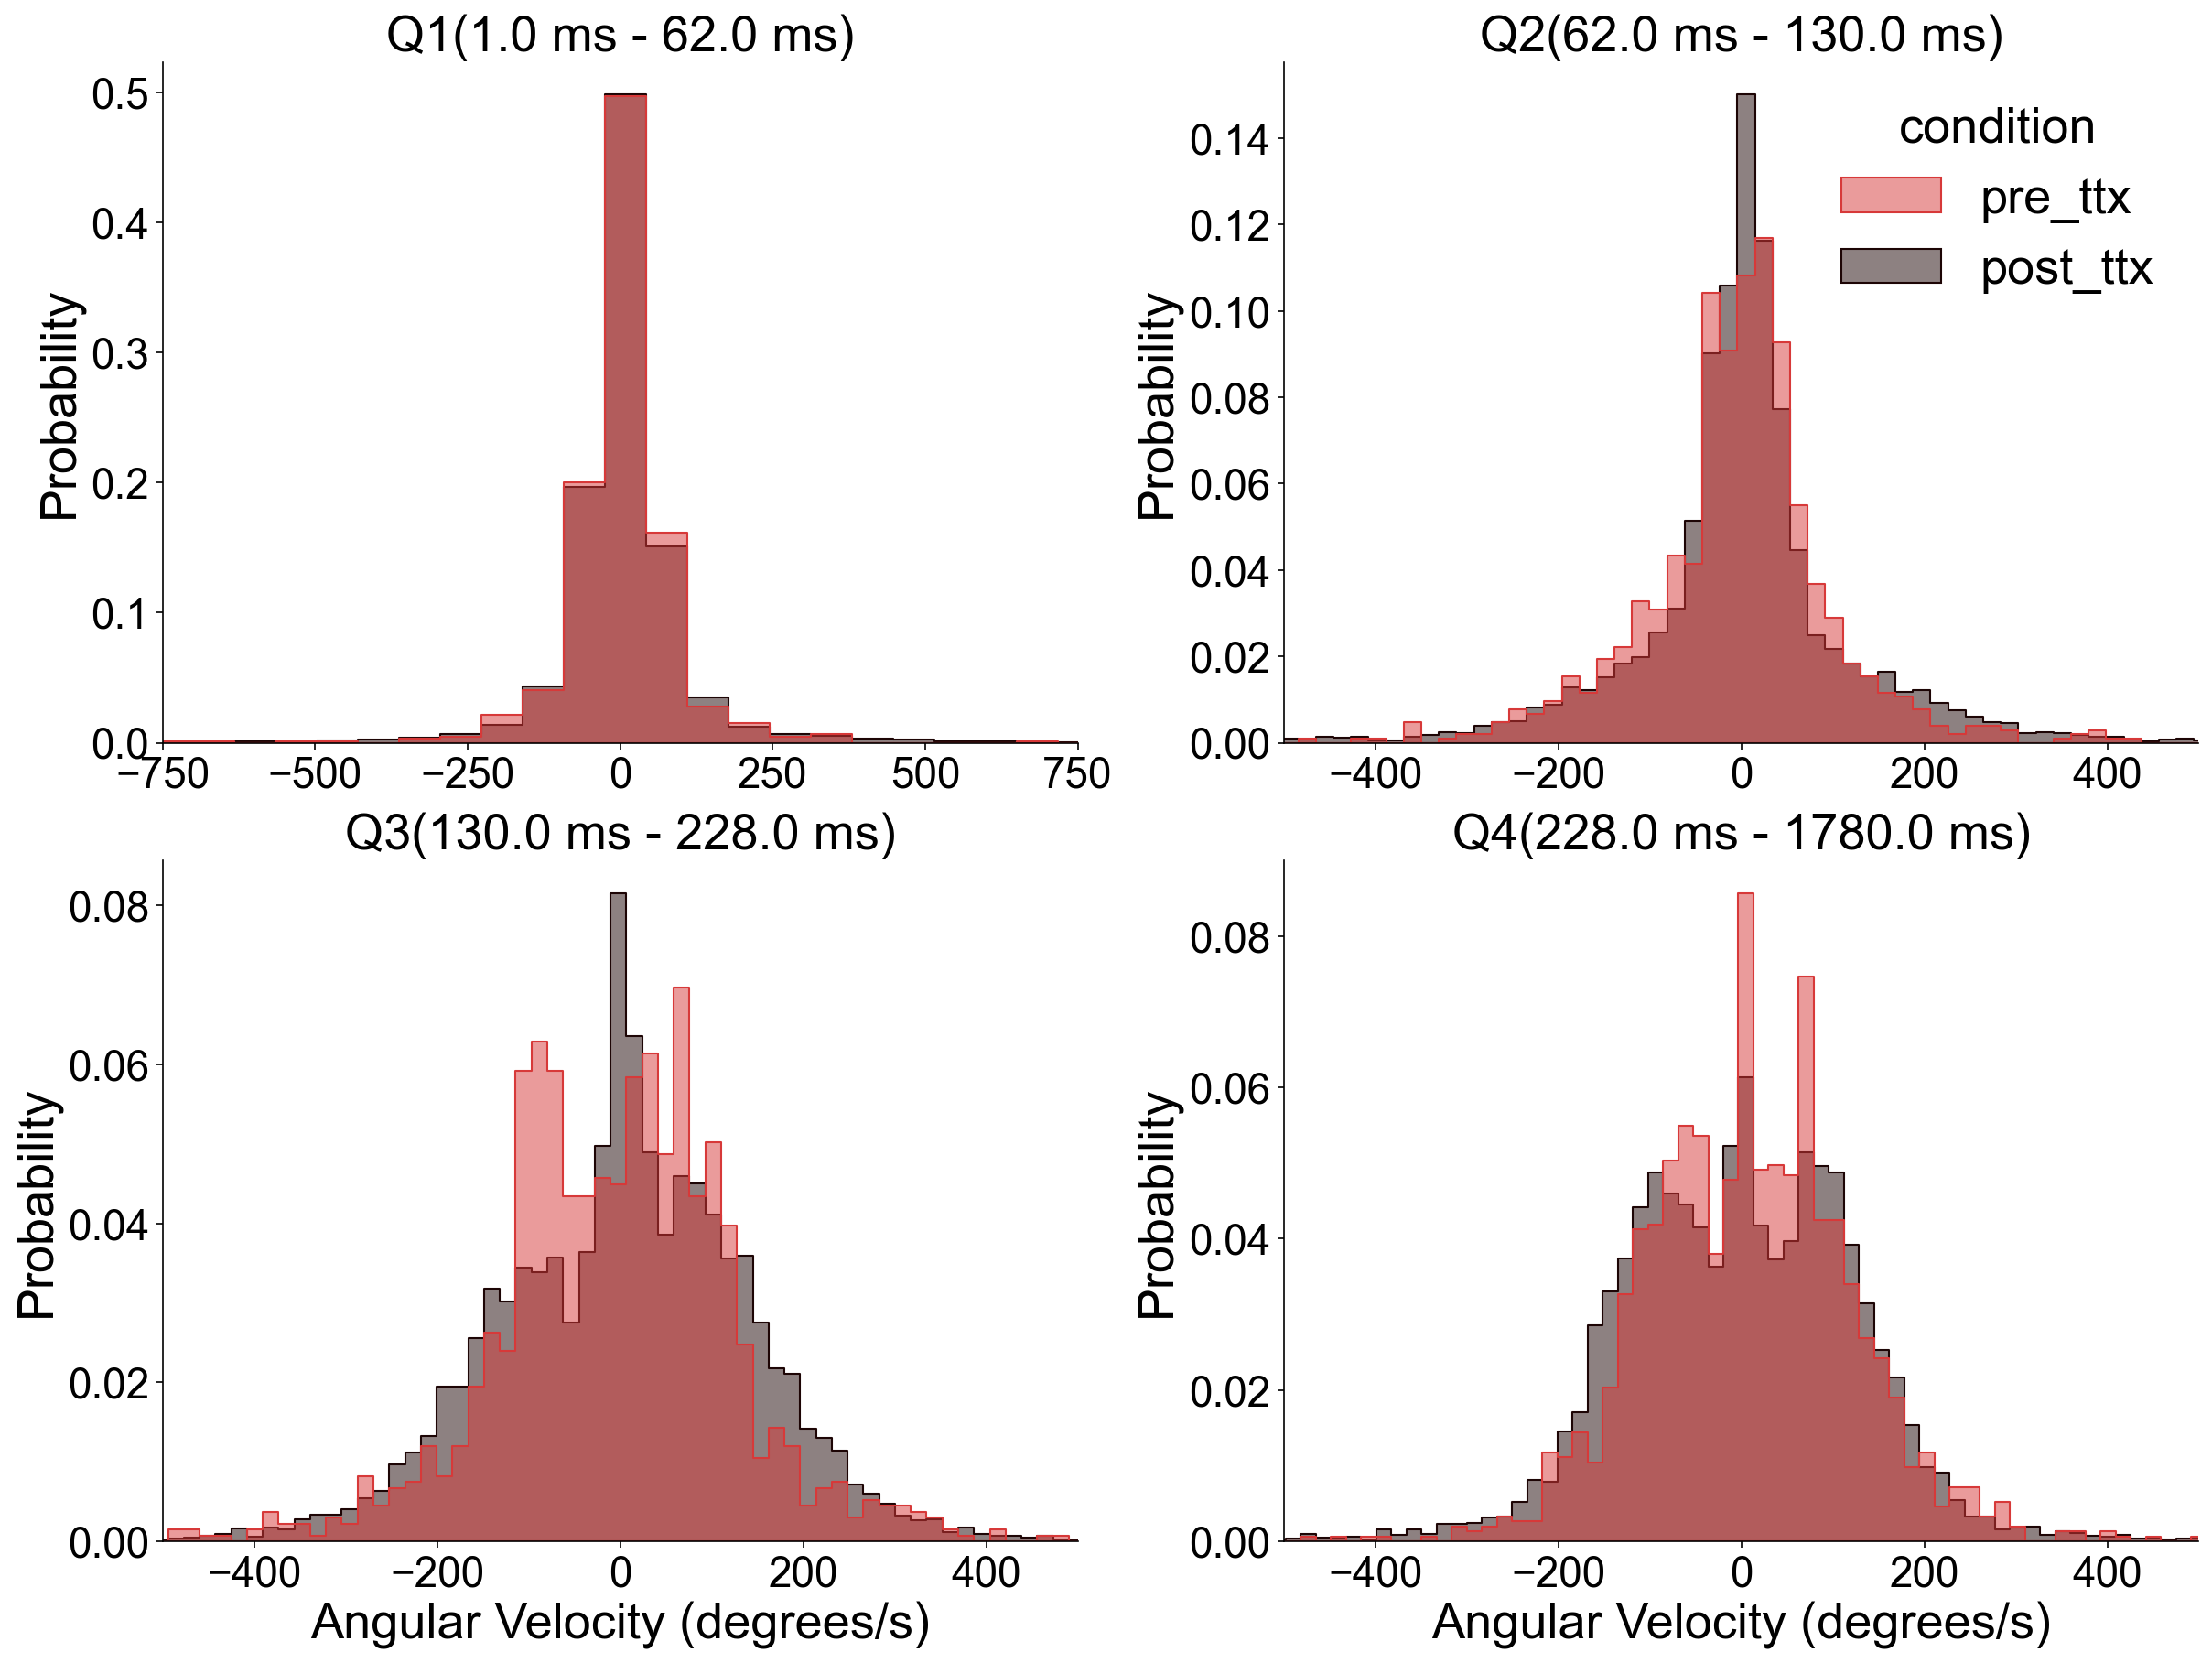

In [11]:
palette = ["#d73939", "#1d0505ff"]
kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# fig.suptitle(f'Sweep Angular Velocity by Quartile (Threshold: {threshold*100:.0f}%)(Mouse {UNIT})', fontsize=18)

axes[0, 0] = sns.histplot(data=sweeps[sweeps['quartile'] == 0], x='velocity', hue='condition', **kwargs, ax=axes[0, 0], legend=False)
axes[0, 0].set_title(f'Q1({stats["min"]*1000:.1f} ms - {stats["25%"]*1000:.1f} ms)')
axes[0, 0].set_xlabel('')
axes[0, 0].set_xlim(-750, 750)

axes[0, 1] = sns.histplot(data=sweeps[sweeps['quartile'] == 1], x='velocity', hue='condition', **kwargs, ax=axes[0, 1])
axes[0, 1].set_title(f'Q2({stats["25%"]*1000:.1f} ms - {stats["50%"]*1000:.1f} ms)')
axes[0, 1].set_xlabel('')
axes[0, 1].set_xlim(-500, 500)

axes[1, 0] = sns.histplot(data=sweeps[sweeps['quartile'] == 2], x='velocity', hue='condition', **kwargs, ax=axes[1, 0], legend=False)
axes[1, 0].set_title(f'Q3({stats["50%"]*1000:.1f} ms - {stats["75%"]*1000:.1f} ms)')
axes[1, 0].set_xlabel('Angular Velocity (degrees/s)')
axes[1, 0].set_xlim(-500, 500)

axes[1, 1] = sns.histplot(data=sweeps[sweeps['quartile'] == 3], x='velocity', hue='condition', **kwargs, ax=axes[1, 1], legend=False)
axes[1, 1].set_title(f'Q4({stats["75%"]*1000:.1f} ms - {stats["max"]*1000:.1f} ms)')
axes[1, 1].set_xlabel('Angular Velocity (degrees/s)')
axes[1, 1].set_xlim(-500, 500)

# fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / UNIT / 'figures' / 'sweep_angular_velocity_quartiles_hist.pdf', format='pdf', dpi=1200)

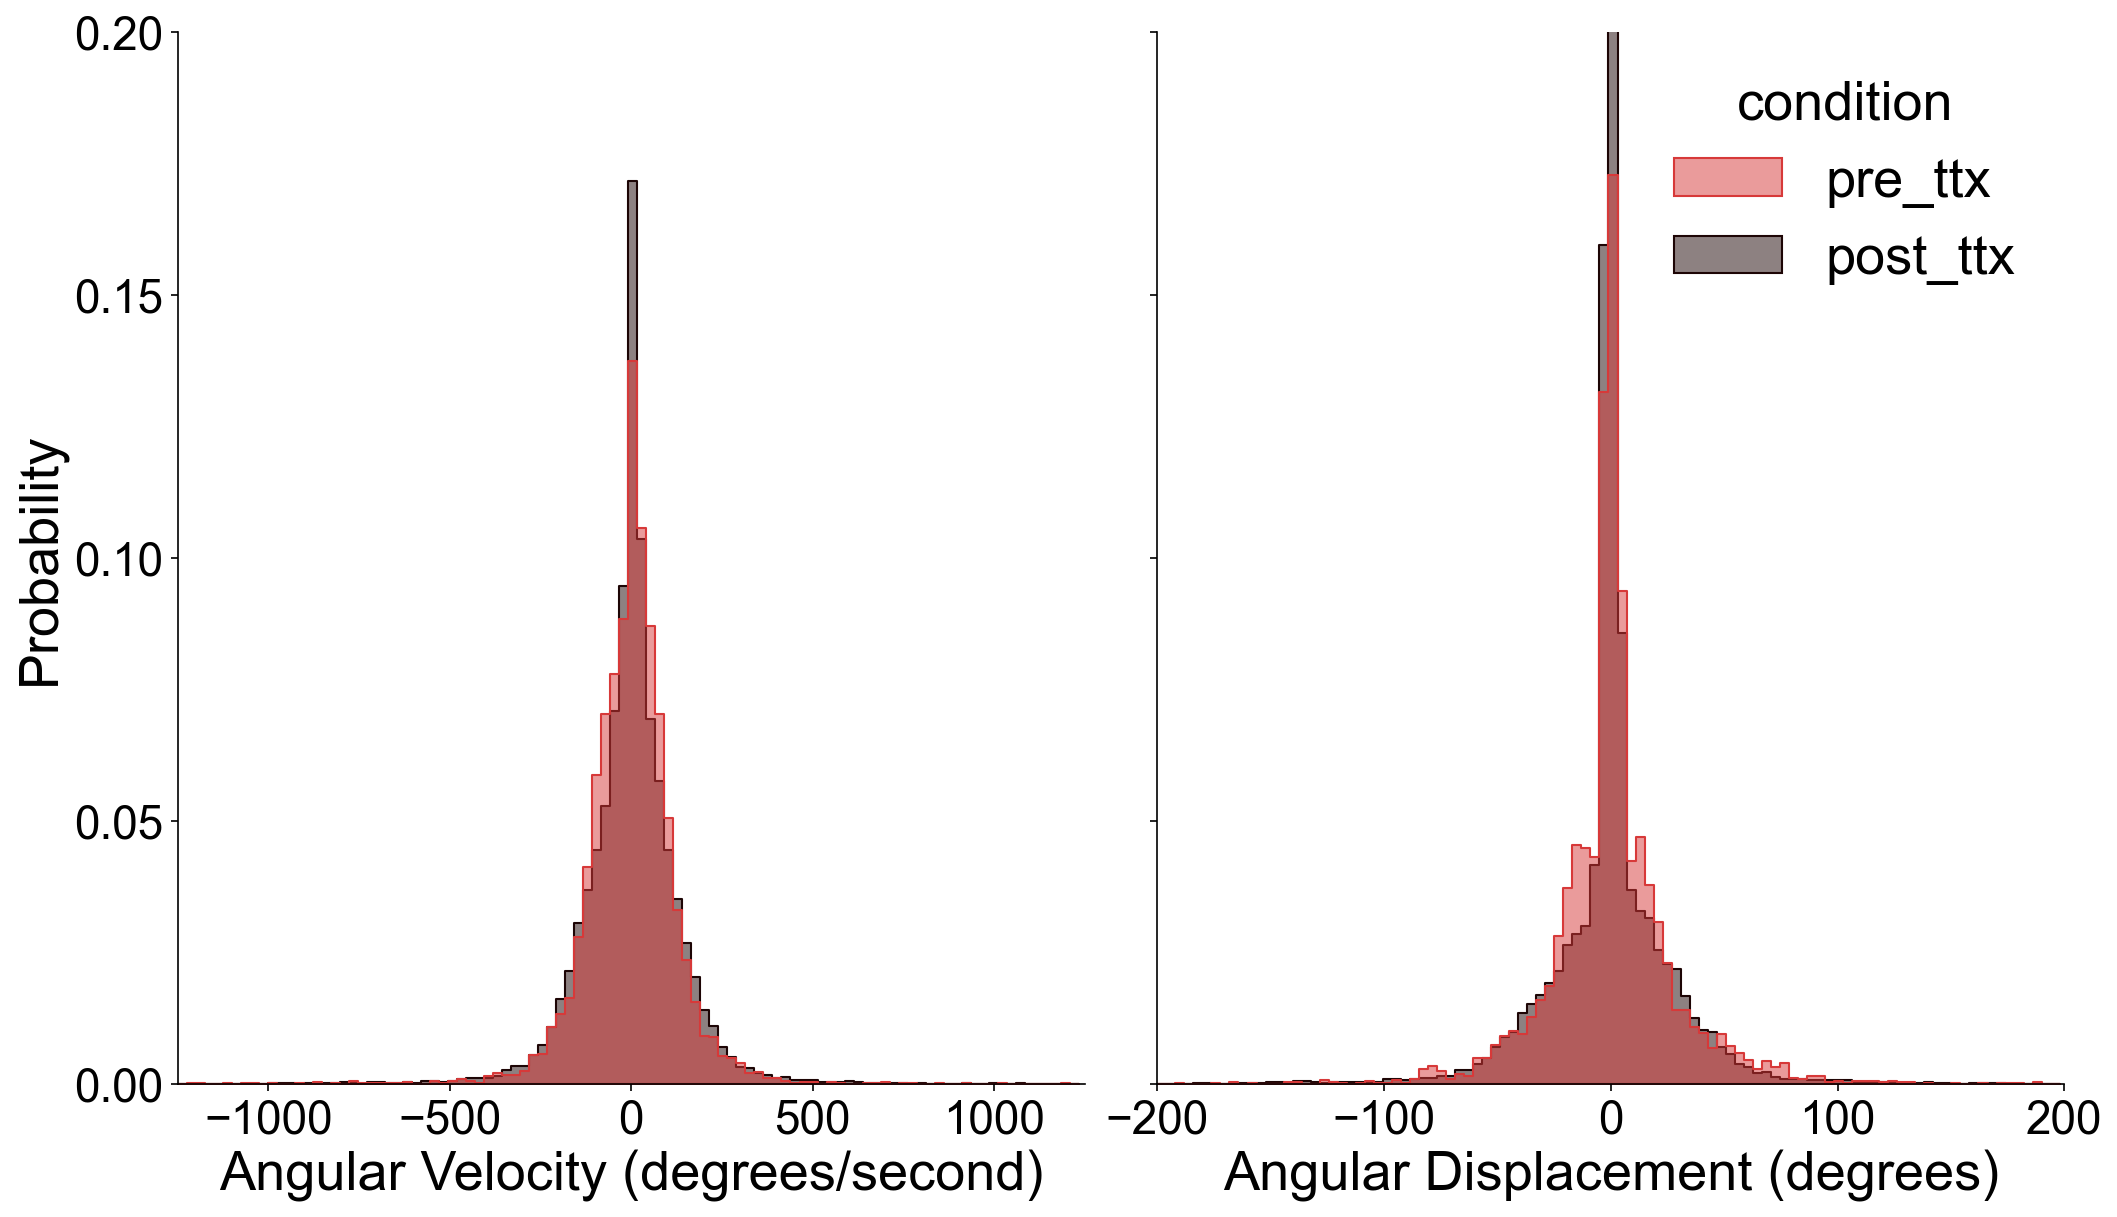

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

palette = ["#d73939", "#1d0505ff"]
kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette, bins=100)

mask = sweeps[sweeps['sleep_state'] == 'nrem']['velocity'].abs() < 1250
axes[0] = sns.histplot(data=(sweeps[sweeps['sleep_state'] == 'nrem'][mask]), x='velocity', hue='condition', **kwargs, ax=axes[0], legend=False)
axes[0].set_xlabel('Angular Velocity (degrees/second)')
axes[0].set_xlim(-1250, 1250)
axes[0].set_ylim(0, 0.2)
axes[0].set_yticks([0, 0.05, 0.1, 0.15, 0.2])

mask = sweeps[sweeps['sleep_state'] == 'nrem']['net_displacement'].abs() < 200
axes[1] = sns.histplot(data=sweeps[sweeps['sleep_state'] == 'nrem'][mask], x='net_displacement', hue='condition', **kwargs, ax=axes[1])
axes[1].set_xlabel('Angular Displacement (degrees)')
axes[1].set_xlim(-200, 200)

# fig.tight_layout()
fig.savefig(INTERIM_DATA_PATH / UNIT / 'figures' / 'sweep_combined_hist.pdf', format='pdf', dpi=1200)